# Advanced Megamicros Features (v3.1)
® *Copyright Bimea 2024-2026*

This notebook demonstrates advanced features of the `Megamicros` class with real USB hardware.

## Prerequisites

- **For USB**: Megamicros hardware connected (Mu32-64-128, Mu256, or Mu1024)
- **For testing**: No hardware needed - uses `RandomDataSource`

Let's explore advanced configurations!

In [ ]:
import time
import numpy as np
import megamicros

import matplotlib.pyplot as plt
from megamicros import Megamicros, AcquisitionConfig
from megamicros.log import log


# Set log level to INFO to see device detection
log.setLevel("DEBUG")

print(f"Megamicros version: {megamicros.__version__}")

## Initialize Antenna (Auto-Detection)

The `Megamicros` class automatically detects available sources:
- USB hardware (if connected)
- Falls back to RandomDataSource (for testing)

No hardware required to run this notebook!

In [ ]:
# Auto-detect source
antenna = Megamicros() 

# Get comprehensive info
info = antenna.infos
print(f"\n{'='*60}")
print(f"ANTENNA INFORMATION")
print(f"{'='*60}")
print(f"Source type: {info['source_type']}")
print(f"Hardware: {info.get('hardware', 'N/A')}")
print(f"Available MEMS: {len(antenna.available_mems)}")
print(f"Available Analogs: {len(antenna.available_analogs)}")
print(f"Max sampling frequency: {info.get('max_sampling_frequency', 'N/A')} Hz")
print(f"{'='*60}\n")


## Available MEMS and Analog Channels

Check what inputs are available on your antenna:

In [ ]:
print(f"Available MEMS: {antenna.available_mems}")
print(f"Available Analog channels: {antenna.available_analogs}")

# Common configurations:
# - Mu32: 32 MEMS, 0-2 analog channels
# - Mu256: 256 MEMS, 0 analog channels  
# - Mu1024: 1024 MEMS, 0 analog channels
# - RandomDataSource: 32 MEMS, 2 analog channels (default)

## Basic Acquisition: All MEMS

Acquire 1 second on all available channels (both MEMS and analogs).

In [ ]:
# v3.1: All parameters in run()
antenna.run(
    mems=antenna.available_mems,
    duration=1,
    sampling_frequency=50000,
    counter=True  # Add counter channel
)

antenna.wait()

print(f"✓ Acquisition complete!")
print(f"✓ Frames in queue: {antenna.queue_content}")
print(f"✓ Active MEMS: {len(antenna.mems)}")
print(f"✓ Active counters: {len(antenna.counter)}")

## Retrieving Data

Iterate through the antenna to get frames:

In [ ]:
# Before iteration
print(f"Queue content before: {antenna.queue_content} frames")

# Retrieve frames
frames = []
for frame in antenna:
    frames.append(frame)
    if len(frames) <= 3:  # Show first 3
        print(f"  Frame {len(frames)}: shape={frame.shape}")

# After iteration
print(f"Retrieved {len(frames)} frames total")
print(f"Queue content after: {antenna.queue_content} frames")

Plot MEMS and counter signals

In [ ]:
signal = np.concatenate(frames, axis=1)
print(f"data shape: {signal.shape}")

# Create time axis (in seconds)
time = np.arange(signal.shape[1]) / antenna.sampling_frequency

counter = signal[0, :]
mems_0 = signal[1, :]

# Plot counter, mems_0 ans analog_0 signals
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(time, counter, label='Counter')
plt.title('Counter Channel')
plt.xlabel('Time (s)')
plt.ylabel('Counter Value')
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(time, mems_0, label='MEMS 0')
plt.title('MEMS 0 Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


## Basic Acquisition: All MEMS + Analogs

Acquire 1 second on all available channels (both MEMS and analogs).

In [ ]:
# v3.1: All parameters in run()
antenna.run(
    mems=antenna.available_mems,
    analogs=antenna.available_analogs,  # Include analog channels
    duration=1,
    sampling_frequency=50000,
    counter=True  # Add counter channel
)

antenna.wait()

print(f"✓ Acquisition complete!")
print(f"✓ Frames in queue: {antenna.queue_content}")
print(f"✓ Active MEMS: {len(antenna.mems)}")
print(f"✓ Active analogs: {len(antenna.analogs)}")
print(f"✓ Active counters: {len(antenna.counter)}")

## Retrieving Data

Iterate through the antenna to get frames:

In [ ]:
# Before iteration
print(f"Queue content before: {antenna.queue_content} frames")

# Retrieve frames
frames = []
for frame in antenna:
    frames.append(frame)
    if len(frames) <= 3:  # Show first 3
        print(f"  Frame {len(frames)}: shape={frame.shape}")

# After iteration
print(f"Retrieved {len(frames)} frames total")
print(f"Queue content after: {antenna.queue_content} frames")


Plot counter, first MEMS and first analog channel:

In [ ]:
signal = np.concatenate(frames, axis=1)
print(f"data shape: {signal.shape}")

# Create time axis (in seconds)
time = np.arange(signal.shape[1]) / antenna.sampling_frequency

counter = signal[0, :]
mems_0 = signal[1, :]
analog_0 = signal[1 + len(antenna.mems), :]

# Plot counter, mems_0 ans analog_0 signals
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(time, counter, label='Counter')
plt.title('Counter Channel')
plt.xlabel('Time (s)')
plt.ylabel('Counter Value')
plt.grid()
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(time, mems_0, label='MEMS 0')
plt.title('MEMS 0 Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(time, analog_0, label='Analog 0')
plt.title('Analog Channel 0')
plt.xlabel('Time (s)')
plt.ylabel('Voltage')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

## Selective MEMS Activation

Activate only specific MEMS channels. Inactive MEMS will be filled with zeros.

**v3.0 improvement**: Clear validation errors if you request invalid MEMS.

In [ ]:
# Perform hardware self-test (USB only, skipped on RandomDataSource)
try:
    check = antenna.selftest()
    print("✓ Self-test passed")
except AttributeError:
    print("⚠ Self-test not available (not USB source)")

connected_mems = check.get("connected_mems", [])
connected_analogs = check.get("connected_analogs", [])

print(f"Available MEMS: {connected_mems}")
print(f"Available Analogs: {connected_analogs}")

### Activate Non-Available MEMS

You can request MEMS that aren't available - they'll be filled with zeros.

**Limitation**: Cannot exceed hardware maximum (e.g., can't request MEMS 128 on a Mu32).

In [ ]:
# Example: Activate a MEMS that might not be available
# (This works because non-available MEMS are filled with zeros)
antenna.run(
    mems=[0, 18],  # MEMS 18 might be unavailable (hardware-dependent)
    duration=0.5,
    counter=True
)

antenna.wait()

print(f"Queue content: {antenna.queue_content} frames")

# Show first frame
for frame in antenna:
    print(f"Frame shape: {frame.shape}")
    print(f"MEMS 0 (active): min={frame[1].min()}, max={frame[1].max()}")
    print(f"MEMS 18 (may be inactive): min={frame[2].min()}, max={frame[2].max()}")
    break  # Show only first frame

## Comprehensive Configuration

Pass all settings to `run()` for full control:

In [ ]:
antenna.run(
    duration=1,                           # 1 second acquisition
    mems=antenna.available_mems[:8],      # First 8 MEMS
    analogs=antenna.available_analogs,    # All analogs
    counter=True,                         # Include counter channel
    datatype='int32',                     # Raw ADC values
    sampling_frequency=50000,             # 50 kHz
    frame_length=1024                     # 1024 samples per frame
)

antenna.wait()

# Calculate expected frames
expected_frames = (1 * 50000) // 1024  # duration * fs / frame_length
print(f"✓ Expected ~{expected_frames} frames")
print(f"✓ Got {antenna.queue_content} frames")

In [ ]:
# Minimal run - only change MEMS selection
antenna.run(mems=[0, 10], duration=1)

antenna.wait()

print(f"✓ Acquired with MEMS: {antenna.mems}")

## Real-Time Processing

`run()` is **non-blocking** - you can process frames as they arrive!

**Critical workflow**:
1. Call `run()` (non-blocking)
2. Iterate to process frames in real-time
3. Call `wait()` to ensure cleanup

In [ ]:
log.setLevel("WARNING")  # Reduce verbosity

antenna.run(
    duration=1,
    mems=[0, 1],
    counter=True
)

# Process frames in real-time
processed_count = 0
for frame in antenna:
    counter_value = int(frame[0, 0])
    print(f"Real-time processing frame #{counter_value:05d}")
    processed_count += 1

antenna.wait()  # ← MANDATORY!

print(f"\n✓ Processed {processed_count} frames in real-time")
print(f"✓ Queue now empty: {antenna.queue_content} frames")

## Timing Analysis

Measure end-to-end acquisition time including all overheads.

In [ ]:
start_time = time.time()

antenna.run(
    duration=1,
    mems=[0, 1],
    counter=True,
    queue_timeout=1000  # Default: 1000ms
)

# Collect counter values
counter_values = []
for frame in antenna:
    counter_values.append(int(frame[0, 0]))

antenna.wait()

elapsed = time.time() - start_time

print(f"Requested duration: 1.0 second")
print(f"Actual elapsed time: {elapsed:.2f} seconds")
print(f"Frames received: {len(counter_values)}")
print(f"Counter range: {min(counter_values)} → {max(counter_values)}")

## Understanding Timing Overheads

Total elapsed time includes:
- **MEMS activation delay**: Default 200ms (USB only, hardware settling time)
- **Acquisition time**: Requested duration
- **Queue timeout**: Default 1000ms (wait for last frame)

**Total ≈ 0.2s + 1.0s + 1.0s = 2.2s** (for USB)

For RandomDataSource, no activation delay, so **Total ≈ 1.0s + 1.0s = 2.0s**

### Reducing Activation Delay (USB Only)

You can reduce or eliminate the MEMS powering delay if needed:

In [ ]:
log.setLevel("WARNING")

start_time = time.time()

antenna.run(
    duration=1,
    mems=[0, 1],
    counter=True,
    time_activation=0  # No MEMS powering delay (USB only)
)

# Collect counter and MEMS data
counter_data = []
mems_0_data = []

for frame in antenna:
    counter_data.extend(frame[0, :])      # Counter channel
    mems_0_data.extend(frame[1, :])      # MEMS 0 channel

antenna.wait()

elapsed = time.time() - start_time

# Convert to numpy arrays
counter = np.array(counter_data, dtype=int)
mems_0 = np.array(mems_0_data, dtype=float)

# Convert to physical units (Pascals)
signal = mems_0 * antenna.mems_sensibility

# Time axis
t = np.arange(len(mems_0)) / antenna.sampling_frequency

print(f"Elapsed time (no activation delay): {elapsed:.2f} seconds")
print(f"Samples collected: {len(mems_0)}")
print(f"MEMS sensibility: {antenna.mems_sensibility:.2e} Pa/digit")

# Plot MEMS 0 signal
plt.figure(figsize=(12, 4))
plt.plot(t, signal)
plt.title('MEMS 0 Activity (time_activation=0)')
plt.xlabel('Time (seconds)')
plt.ylabel('Pressure (Pascals)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Show counter values (first 20)
print(f"\nFirst 20 counter values: {counter[:20]}")
print(f"⚠ Note: Initial values may be lower due to startup settling")

### Transient Analysis

With `time_activation=0`, you'll see a **transient state** in the first ~200ms:
- MEMS are powering up
- ADC values stabilize
- Counter may have lower initial values

**Recommendation**: Use default `time_activation=200` (ms) for USB hardware unless you need ultra-fast startup.

## Analog Input Channels

Megamicros systems can include analog inputs for external sensors:
- **Mu32**: 0-2 analog channels (hardware-dependent)
- **Mu64**: 2 analog channels
- **Mu128/256**: 4 analog channels
- **Mu512/Mu1024**: 8/16 channels
- **RandomDataSource**: 2 analog channels (simulated)

Analog data is interleaved with MEMS data in each frame.

In [ ]:
print(f"Available analog channels: {antenna.available_analogs}")

if len(antenna.available_analogs) > 0:
    antenna.run(
        duration=1,
        mems=[0, 1],
        analogs=antenna.available_analogs[:2],  # First 2 analogs
        counter=True,
        datatype='int32',
        sampling_frequency=50000
    )
    
    antenna.wait()
    
    # Collect one frame to show structure
    for frame in antenna:
        print(f"\nFrame structure:")
        print(f"  Total channels: {frame.shape[0]}")
        print(f"  Samples per frame: {frame.shape[1]}")
        print(f"  Channel 0: Counter")
        print(f"  Channels 1-2: MEMS 0-1")
        print(f"  Channels 3-{frame.shape[0]-1}: Analog inputs")
        break
    
else:
    print("⚠ No analog channels available on this source")
    print("💡 Use Mu32 hardware or RandomDataSource to test analog inputs")

## NEW in v3.1: Type-Safe Configuration

Use `AcquisitionConfig` for validated, reusable configurations:

In [ ]:
# Create configuration object
config = AcquisitionConfig(
    mems=[0, 1, 2, 3],
    analogs=[0] if len(antenna.available_analogs) > 0 else [],
    sampling_frequency=50000,
    frame_length=2048,
    duration=1.0,
    datatype='float32',  # Auto-converts to Pascals!
    counter=True
)

# Inspect computed properties
print("Configuration:")
print(f"  Sampling frequency: {config.sampling_frequency} Hz")
print(f"  Frame length: {config.frame_length} samples")
print(f"  Duration: {config.duration}s")
print(f"  Total samples: {config.total_samples}")
print(f"  Expected frames: {config.total_frames}")
print(f"  Active channels: {config.channels_number}")
print(f"  Datatype: {config.datatype}")

# Use configuration (unpack dict)
antenna.run(**config.__dict__)

# Collect signal
frames = []
for frame in antenna:
    frames.append(frame)

antenna.wait()

# Concatenate all frames
signal = np.concatenate(frames, axis=1)

print(f"\n✓ Collected signal: {signal.shape}")
print(f"✓ Datatype: {signal.dtype} ({'Pascals' if signal.dtype == np.float32 else 'ADC values'})")
print(f"✓ Duration: {signal.shape[1] / config.sampling_frequency:.3f}s")

## Data Type Conversion: int32 vs float32

**int32**: Raw ADC values (24-bit signed, stored as int32)  
**float32**: Automatically converted to **Pascals** using MEMS sensibility

**Default sensibility**: `3.54e-6 Pa/digit` (can be calibrated per-antenna)

In [1]:
import time
import numpy as np
import megamicros

import matplotlib.pyplot as plt
from megamicros import Megamicros, AcquisitionConfig
from megamicros.log import log


# Set log level to INFO to see device detection
log.setLevel("INFO")

print(f"Megamicros version: {megamicros.__version__}")

antenna = Megamicros()

2026-04-06 22:36:11,654 [INFO]: Creating UsbDataSource (0xfe27:0xac03)
2026-04-06 22:36:11,655 [INFO]: UsbDataSource initialized: 32 MEMS available


Megamicros version: 3.1.0


2026-04-06 22:38:13,870 [INFO]: USB configured: 8192 bytes/frame, 2 channels, 8 buffers
2026-04-06 22:38:13,876 [INFO]: RESET and PURGE commands sent to FPGA
2026-04-06 22:38:13,879 [INFO]: Sampling frequency 44100Hz sent as clockdiv 10 (nearest activated frequency is 45454Hz)
2026-04-06 22:38:13,881 [INFO]: Active channels sent to FPGA: MEMS=1, Analogs=0, Counter=1, Status=False
2026-04-06 22:38:13,884 [INFO]: Datatype sent to FPGA: int32
2026-04-06 22:38:13,887 [INFO]: Sample count sent to FPGA: 0 (streaming mode if 0)
2026-04-06 22:38:13,888 [INFO]: Starting USB acquisition...
2026-04-06 22:38:13,890 [INFO]: START command sent to FPGA
2026-04-06 22:38:13,891 [INFO]: Starting native USB async bulk transfer (duration=0.5s, expected frames=22)
2026-04-06 22:38:13,892 [INFO]: Init asynchronous bulk transfer...
2026-04-06 22:38:13,892 [INFO]: Starting thread timer for 0.5 seconds...
2026-04-06 22:38:13,893 [INFO]: Starting asynchronous bulk transfer thread...
2026-04-06 22:38:13,894 [INF

Data Type Comparison:
int32 range: -22468 to 73766
int32 dtype: int32

float32 range: -1.99e+04 to 7.21e+04 Pa
float32 dtype: float32

Conversion factor: 1.00e-03 Pa/digit

✓ Manual conversion matches: False


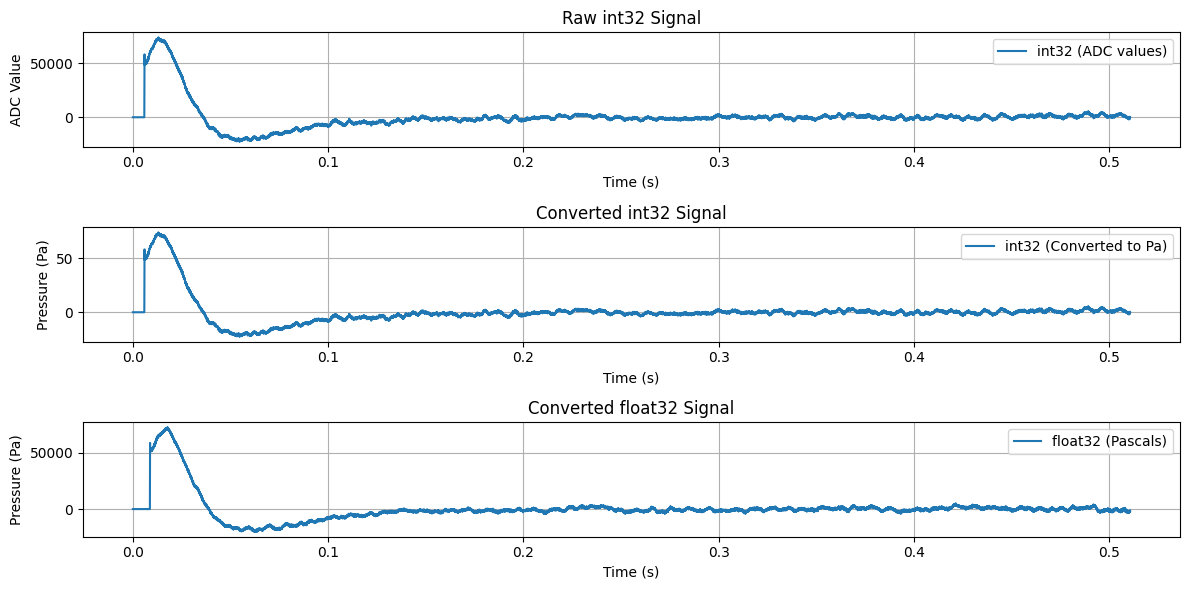

In [ ]:
# Acquire same signal in both formats
configs = [
    AcquisitionConfig(mems=[0], duration=0.5, datatype='int32'),
    AcquisitionConfig(mems=[0], duration=0.5, datatype='float32')
]

results = {}

for cfg in configs:
    antenna.run(**cfg.__dict__)
    
    frames = []
    for frame in antenna:
        frames.append(frame)
    
    antenna.wait()
    
    signal = np.concatenate(frames, axis=1)[1, :]  # First MEMS (counter is 0)
    results[cfg.datatype] = signal

# Compare
print("Data Type Comparison:")
print(f"int32 range: {results['int32'].min()} to {results['int32'].max()}")
print(f"int32 dtype: {results['int32'].dtype}")
print(f"\nfloat32 range: {results['float32'].min():.2e} to {results['float32'].max():.2e} Pa")
print(f"float32 dtype: {results['float32'].dtype}")
print(f"\nConversion factor: {antenna.mems_sensibility:.2e} Pa/digit")

# Verify conversion
converted_manually = results['int32'].astype(float) * antenna.mems_sensibility
print(f"\n✓ Manual conversion matches: {np.allclose(converted_manually, results['float32'])}")

# Plot both signals
time = np.arange(results['int32'].shape[0]) / configs[0].sampling_frequency

plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(time, results['int32'], label='int32 (ADC values)')
plt.title('Raw int32 Signal')
plt.xlabel('Time (s)')
plt.ylabel('ADC Value')
plt.grid()
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(time, converted_manually, label='int32 (Converted to Pa)')
plt.title('Converted int32 Signal')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (Pa)')
plt.grid()
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(time, results['float32'] * antenna.mems_sensibility, label='float32 (Pascals)')
plt.title('Converted float32 Signal')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (Pa)')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()